# 03 - Exploratory Data Analysis

## Objective

The purpose of this notebook is to understand the factors associated with customer churn.

The analysis focuses on two main questions:

1. How serious is customer churn overall?
2. Which customer characteristics and services are associated with higher churn?

The findings from this analysis will later help guide feature engineering and model interpretation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [4]:
df.shape

(7043, 22)

In [5]:
churn_counts = df["Churn"].value_counts()

churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
churn_rate = df["ChurnFlag"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


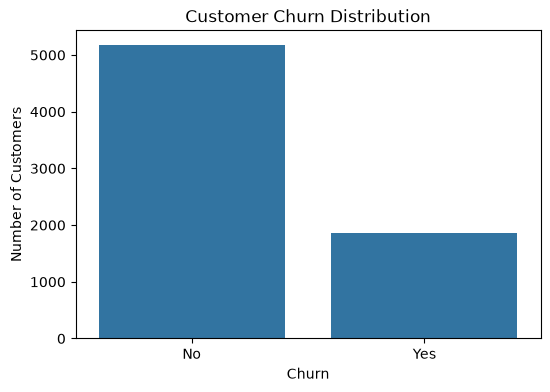

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Business Insight

Approximately 26.5% of customers in the dataset have churned.

Although the majority of customers remain with the company, more than one in four customers leaving represents a meaningful retention problem.

The target variable is also moderately imbalanced, since non-churn customers are much more common than churn customers. Therefore, model evaluation should not rely only on accuracy.

## Churn by Contract Type

Contract type may influence customer retention because customers with longer contracts are usually more committed to the service.

This analysis compares churn rates across:

- Month-to-month contracts
- One-year contracts
- Two-year contracts

In [9]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [10]:
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

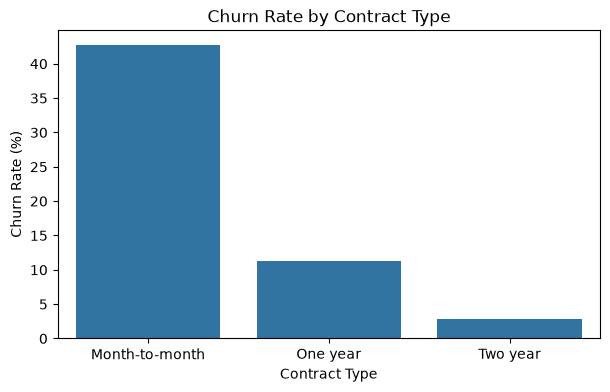

In [11]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

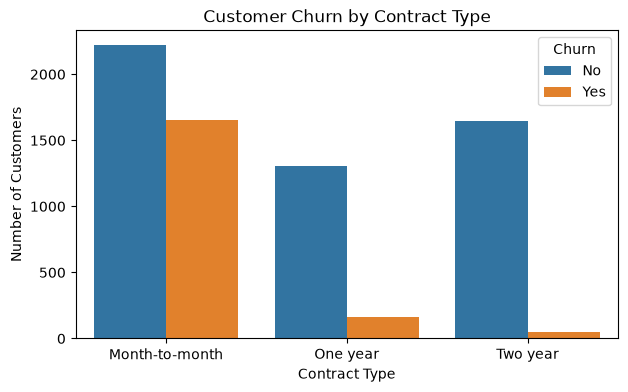

In [12]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Contract type has a strong relationship with customer churn.

- Customers on month-to-month contracts have the highest churn rate at approximately 42.7%.
- Customers on one-year contracts have a much lower churn rate of approximately 11.3%.
- Customers on two-year contracts have the lowest churn rate at approximately 2.8%.

This suggests that customers with longer-term contracts are substantially less likely to churn.

From a business perspective, the company could focus retention campaigns on month-to-month customers and offer incentives for customers to move toward longer-term contracts.

However, this analysis shows association rather than proving that contract type directly causes churn.

In [18]:
contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

## Churn by Customer Tenure

Customer tenure represents the number of months a customer has stayed with the company.

Analyzing tenure helps determine whether churn is concentrated among newer customers or long-term customers.

In [19]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


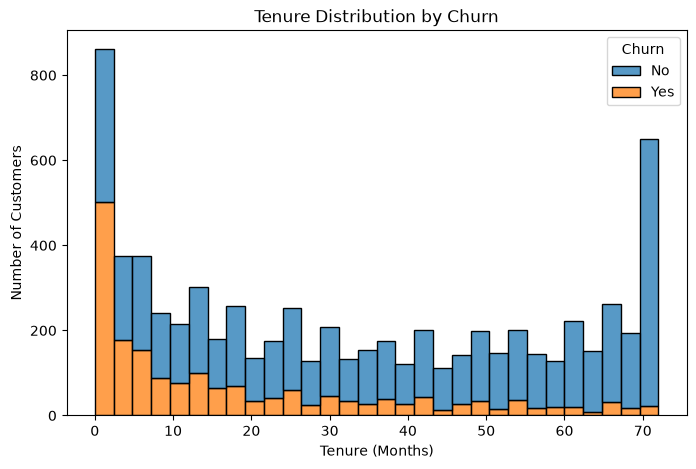

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

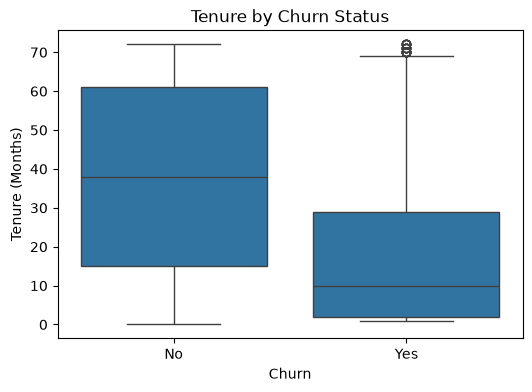

In [21]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Business Insight

Customer tenure shows a strong relationship with churn.

- Customers who churned had an average tenure of approximately 18 months.
- Customers who did not churn had an average tenure of approximately 38 months.
- The median tenure of churned customers is only 10 months, compared with 38 months for non-churned customers.
- The histogram shows that churn is heavily concentrated among customers in the early stages of their relationship with the company.

This suggests that the first few months of the customer lifecycle may be particularly important for retention.

From a business perspective, the company could focus on stronger onboarding, early customer support, and retention offers for newer customers.

This is an association and does not prove that low tenure directly causes churn.

In [23]:
#Next EDA Question 4 — Monthly Charges vs Churn

## Monthly Charges and Churn

Monthly charges may influence customer satisfaction and retention.

This analysis compares the monthly charges of customers who churned with those who remained with the company.

In [24]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


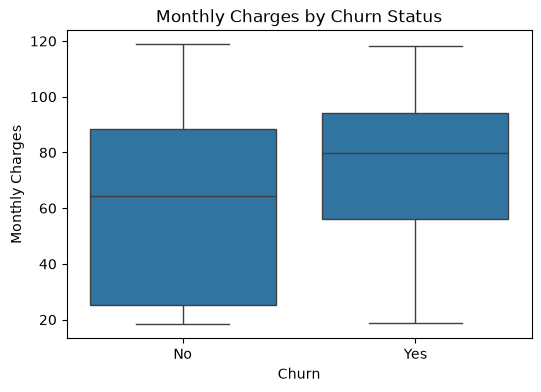

In [25]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

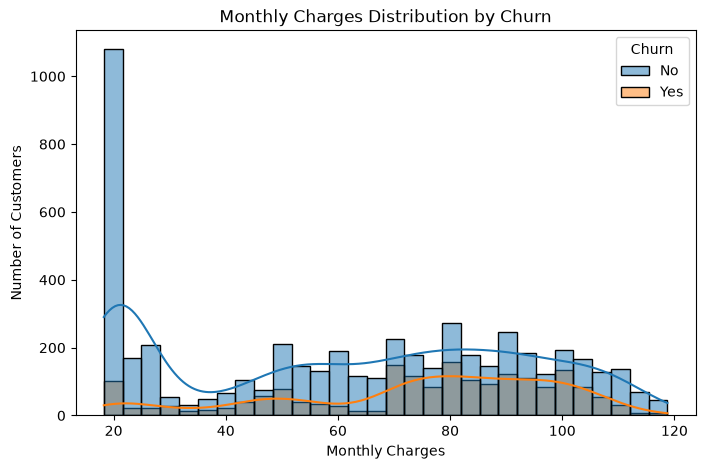

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [27]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


### Business Insight

Monthly charges show a noticeable relationship with churn.

- Customers who churned had an average monthly charge of approximately 74.4.
- Customers who did not churn had an average monthly charge of approximately 61.3.
- The median monthly charge was also higher for churned customers, at about 79.7 compared with 64.4 for non-churned customers.
- The distribution suggests that churned customers are more concentrated in the higher monthly charge range.

This indicates that customers with higher monthly bills may be more sensitive to pricing or may expect greater value from the services they receive.

From a business perspective, the company could investigate high-charge customers more closely and consider targeted offers, service bundles, or retention incentives.

However, higher monthly charges are associated with churn and should not be interpreted as a direct cause without considering other factors such as contract type and internet service.

In [28]:
# Next EDA Question 5 — Internet Service vs Chur

## Churn by Internet Service

Different internet service types may have different pricing, service quality, and customer expectations.

This analysis compares churn rates across:

- DSL
- Fiber optic
- No internet service

In [29]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [30]:
internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

internet_churn

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: ChurnFlag, dtype: float64

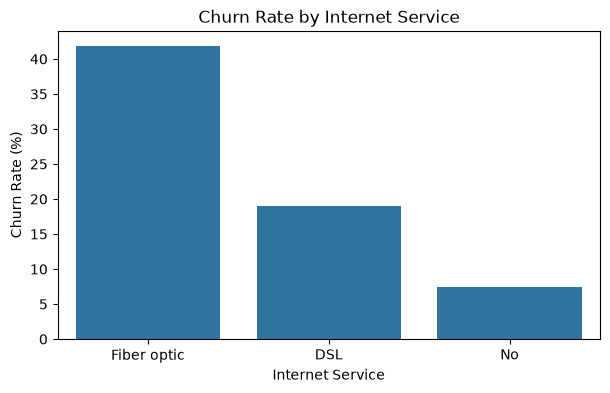

In [31]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

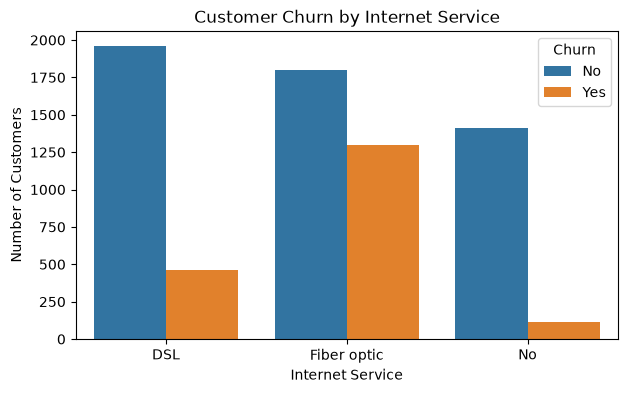

In [32]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Internet service type is strongly associated with customer churn.

- Fiber optic customers have the highest churn rate at approximately 41.9%.
- DSL customers have a much lower churn rate of approximately 19.0%.
- Customers without internet service have the lowest churn rate at approximately 7.4%.

The result suggests that Fiber optic customers represent an important high-risk segment.

Possible reasons may include higher pricing, service expectations, or customer experience issues. However, the dataset does not directly tell us why Fiber optic customers churn more, so these explanations should be treated as hypotheses rather than conclusions.

From a business perspective, the company should investigate Fiber optic customers more closely, particularly their pricing, support experience, and contract type.

In [34]:
# Next EDA Question 6 — Payment Method vs Churn

## Churn by Payment Method

Payment method may be related to customer retention because different payment methods can reflect different levels of convenience, automation, and customer commitment.

This analysis compares churn rates across the available payment methods.|

In [40]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [43]:
payment_churn = (
    df.groupby("PaymentMethod")["ChurnFlag"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
)

payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: ChurnFlag, dtype: float64

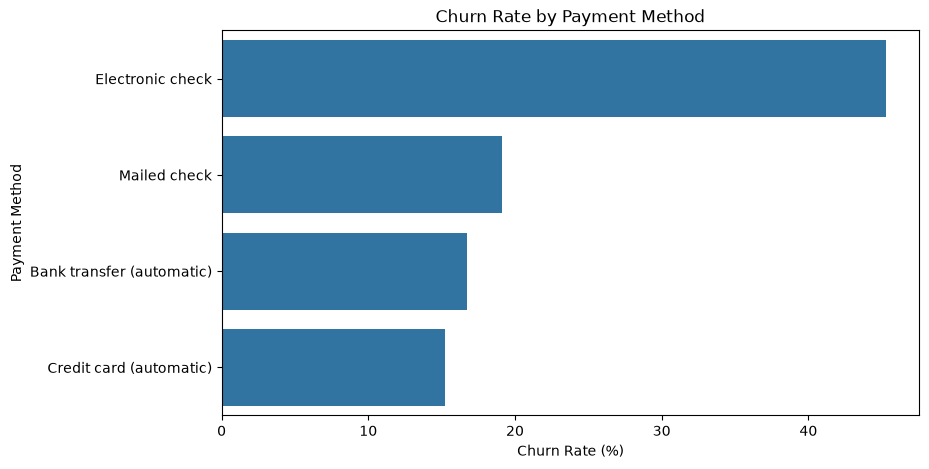

In [39]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_churn.values,
    y=payment_churn.index
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.show()

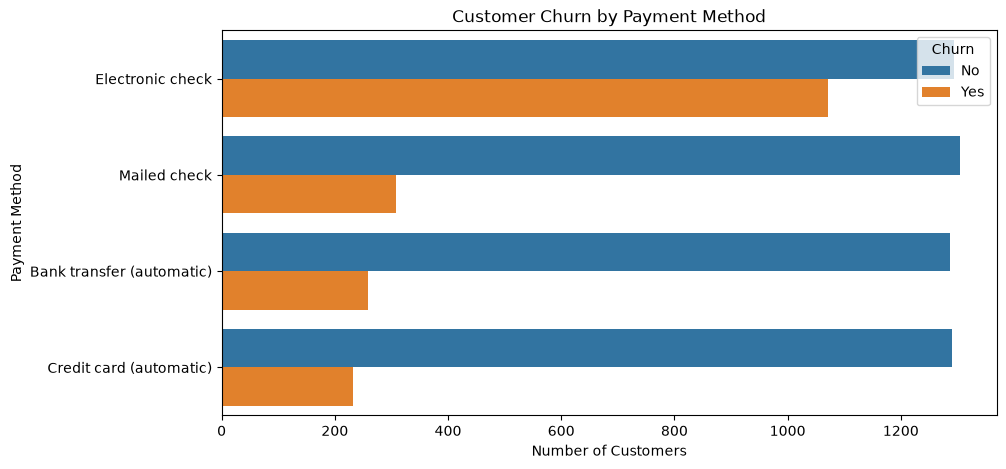

In [44]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Number of Customers")
plt.ylabel("Payment Method")

plt.show()

### Business Insight

Payment method shows a noticeable relationship with customer churn.

- Customers using electronic checks have the highest churn rate at approximately 45.3%.
- Customers using mailed checks have a churn rate of approximately 19.1%.
- Customers using automatic bank t|ransfer and automatic credit card payments have relatively lower churn rates of approximately 16.7% and 15.2%, respectively.

Electronic check customers therefore appear to represent a higher-risk customer segment.

One possible explanation is that automatic payment methods may be associated with greater customer commitment or convenience. However, this cannot be concluded directly from the data because payment method may also be related to other factors such as contract type or tenure.

From a business perspective, the company could investigate whether encouraging customers to use automatic payment methods is associated with improved retention.

In [ ]:
# Next — Senior Citizen vs Churn

## Churn by Senior Citizen Status

Senior citizen status may be associated with different service usage patterns, pricing sensitivity, or support requirements.

This analysis compares churn rates between senior and non-senior customers.

In [45]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [46]:
senior_churn = (
    df.groupby("SeniorCitizen")["ChurnFlag"]
    .mean()
    .mul(100)
)

senior_churn

SeniorCitizen
0    23.606168
1    41.681261
Name: ChurnFlag, dtype: float64

In [47]:
senior_churn.index = ["Not Senior", "Senior"]

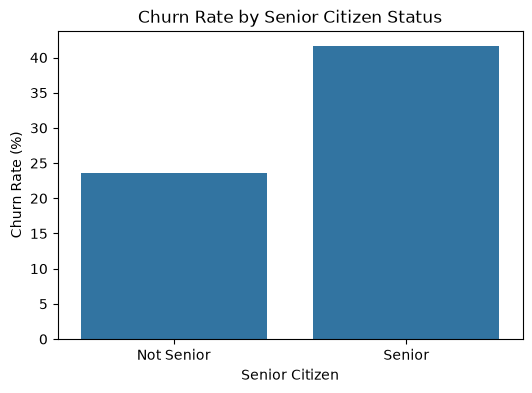

In [48]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

plt.show()

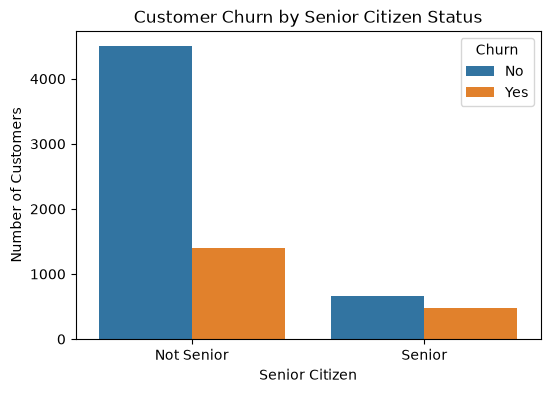

In [49]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.xticks([0, 1], ["Not Senior", "Senior"])
plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Senior citizen status is associated with customer churn.

- Non-senior customers have a churn rate of approximately 23.6%.
- Senior customers have a much higher churn rate of approximately 41.7%.
- Although senior customers make up a smaller portion of the dataset, their likelihood of churn is noticeably higher.

This suggests that senior customers may represent a higher-risk segment.

From a business perspective, the company could investigate whether senior customers would benefit from simpler plans, improved support, or more personalized service.

However, senior citizen status should not be interpreted as a direct cause of churn because it may interact with other factors such as contract type, payment method, tenure, and service usage.

In [ ]:
# Next — Partner vs Churns

## Churn by Partner Status

Having a partner may be associated with customer stability and long-term service usage.

This analysis compares churn rates between customers with and without a partner.

In [50]:
df["Partner"].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [51]:
partner_churn = (
    df.groupby("Partner")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

partner_churn

Partner
No     32.957979
Yes    19.664903
Name: ChurnFlag, dtype: float64

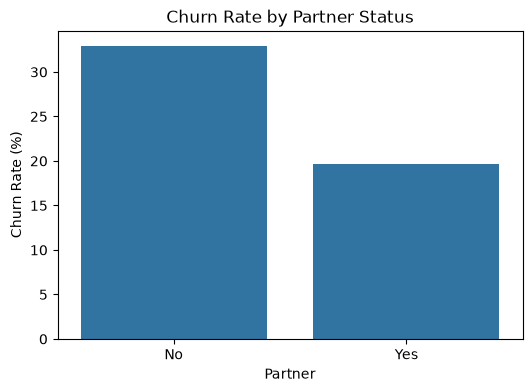

In [52]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=partner_churn.index,
    y=partner_churn.values
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

plt.show()

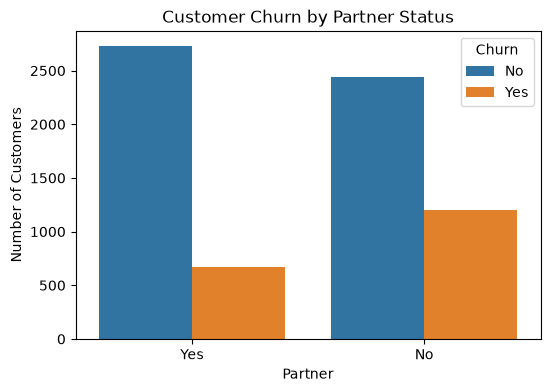

In [53]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Partner status is associated with customer churn.

- Customers without a partner have a churn rate of approximately 33.0%.
- Customers with a partner have a lower churn rate of approximately 19.7%.
- The difference suggests that customers with a partner may be more stable or have longer-term service relationships.

From a business perspective, customers without a partner may represent a relatively higher-risk segment.

However, partner status should not be treated as a direct cause of churn because it may be related to other factors such as tenure, dependents, contract type, and service usage.

In [ ]:
# Next — Dependents vs Churn

## Churn by Dependents

Customers with dependents may have different levels of service stability and long-term commitment.

This analysis compares churn rates between customers with and without dependents.|

In [54]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [56]:
dependents_churn = (
    df.groupby("Dependents")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

dependents_churn

Dependents
No     31.279140
Yes    15.450237
Name: ChurnFlag, dtype: float64

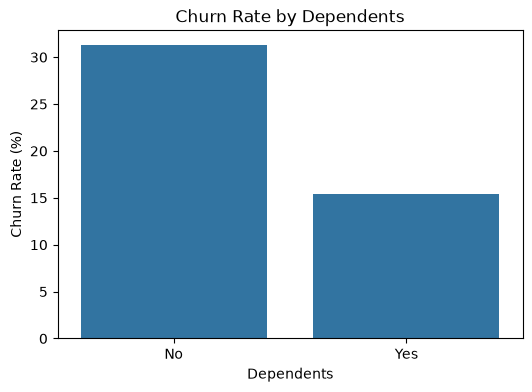

In [57]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=dependents_churn.index,
    y=dependents_churn.values
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

plt.show()

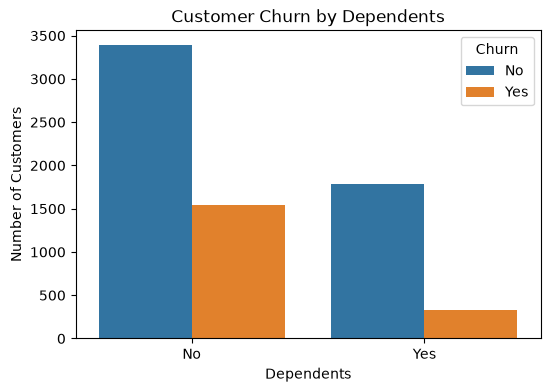

In [58]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Dependents status is associated with customer churn.

- Customers without dependents have a churn rate of approximately 31.3%.
- Customers with dependents have a much lower churn rate of approximately 15.5%.
- This suggests that customers with dependents may have more stable or longer-term service relationships.

From a business perspective, customers without dependents may represent a relatively higher-risk segment.

However, this relationship may overlap with other variables such as partner status, tenure, contract type, and service usage, so it should not be interpreted as a direct causal effect.

In [ ]:
# Next — Tech Support vs Churn

## Churn by Tech Support

Technical support may influence customer satisfaction, especially for customers using internet services.

This analysis compares churn rates across customers with and without technical support.

In [60]:
df["TechSupport"].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [61]:
techsupport_churn = (
    df.groupby("TechSupport")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

techsupport_churn

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: ChurnFlag, dtype: float64

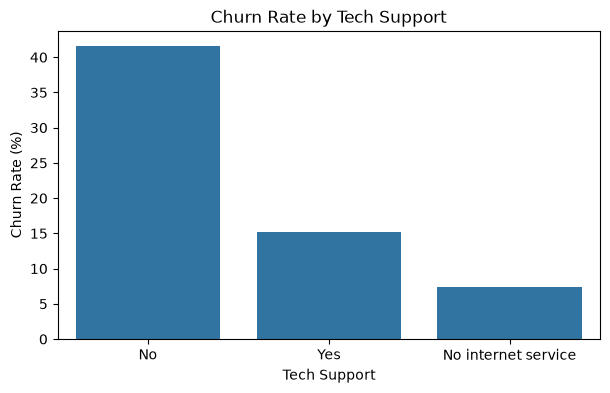

In [62]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=techsupport_churn.index,
    y=techsupport_churn.values
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.show()

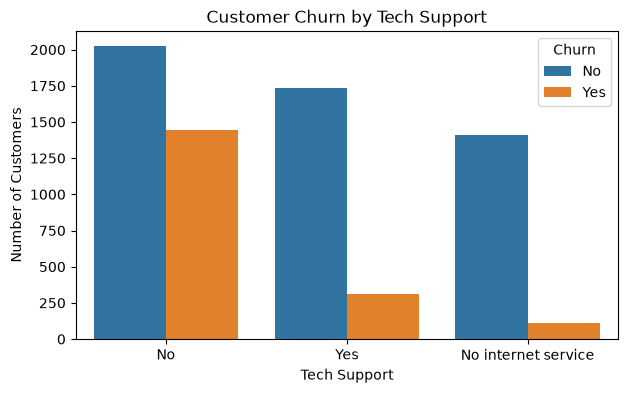

In [63]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Technical support is strongly associated with customer churn.

- Customers without technical support have a churn rate of approximately 41.6%.
- Customers with technical support have a much lower churn rate of approximately 15.2%.
- Customers without internet service have the lowest churn rate at approximately 7.4%.

This suggests that customers without technical support represent an important high-risk segment.

The company could investigate whether providing easier access to technical assistance, support bundles, or proactive customer support improves retention.

However, this relationship does not prove that lack of technical support directly causes churn, since it may also be related to internet service type, pricing, and contract type.

In [ ]:
# Next, do Online Security vs Churn.

## Churn by Online Security

Online security may influence customer retention because customers using additional protection services may have different levels of engagement and perceived value.

This analysis compares churn rates across customers with online security, without online security, and without internet service.

In [64]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [65]:
security_churn = (
    df.groupby("OnlineSecurity")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

security_churn

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: ChurnFlag, dtype: float64

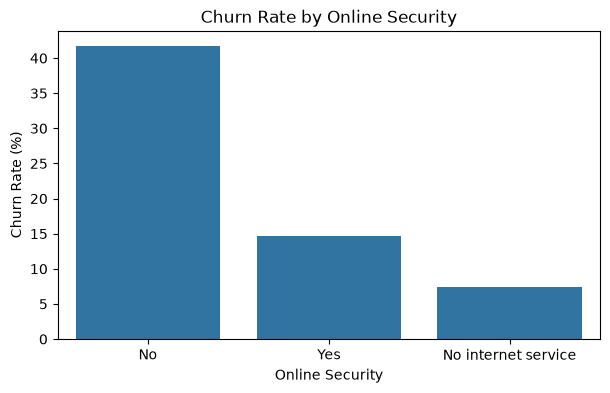

In [66]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=security_churn.index,
    y=security_churn.values
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.show()

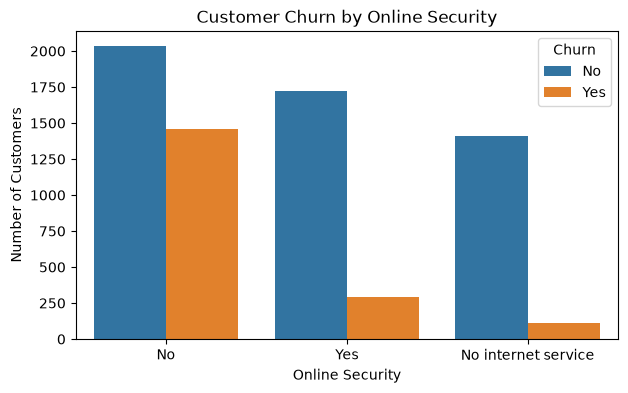

In [67]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Online security is strongly associated with customer churn.

- Customers without online security have a churn rate of approximately 41.8%.
- Customers with online security have a much lower churn rate of approximately 14.6%.
- Customers without internet service have the lowest churn rate at approximately 7.4%.

This suggests that customers without online security represent a higher-risk segment.

From a business perspective, the company could investigate whether security bundles or value-added services are associated with stronger customer retention.

However, online security should not be treated as a direct cause of lower churn because it may also be related to factors such as contract type, tenure, pricing, and internet service.

In [ ]:
# Next — Combined Service Analysis

## Churn Across Additional Services

Instead of analyzing every service individually, this section compares churn rates across several additional services.

The goal is to identify whether customers who subscribe to particular services show noticeably different churn behavior.

In [68]:
service_cols = [
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines"
]

service_results = []

for col in service_cols:
    rates = (
        df.groupby(col)["ChurnFlag"]
        .mean()
        .mul(100)
    )

    for category, rate in rates.items():
        service_results.append({
            "Service": col,
            "Category": category,
            "ChurnRate": rate
        })

service_churn_df = pd.DataFrame(service_results)

service_churn_df

,Service,Category,ChurnRate
0,OnlineBackup,No,39.928756
1,OnlineBackup,No internet service,7.404980
2,OnlineBackup,Yes,21.531494
3,DeviceProtection,No,39.127625
4,DeviceProtection,No internet service,7.404980
5,DeviceProtection,Yes,22.502064
6,StreamingTV,No,33.523132
7,StreamingTV,No internet service,7.404980
8,StreamingTV,Yes,30.070188
9,StreamingMovies,No,33.680431


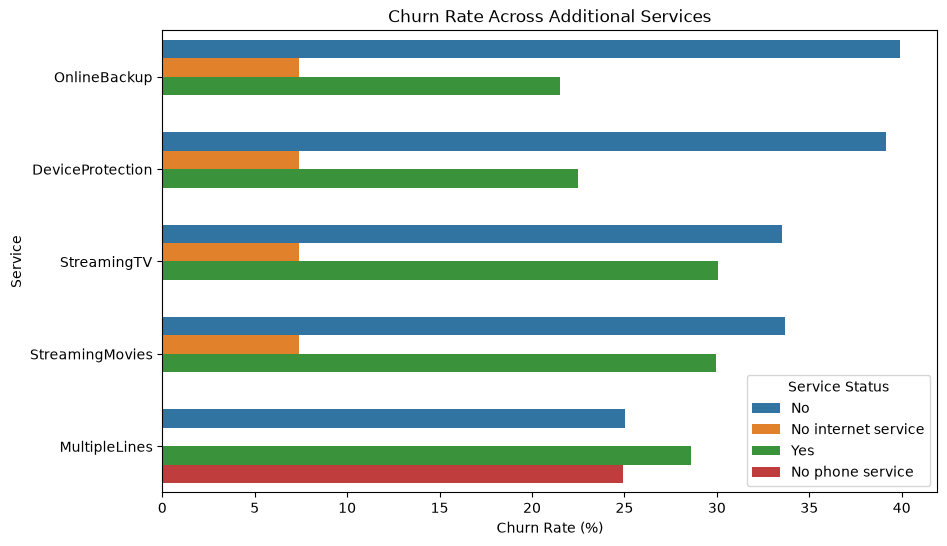

In [69]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=service_churn_df,
    x="ChurnRate",
    y="Service",
    hue="Category"
)

plt.title("Churn Rate Across Additional Services")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Service")

plt.legend(title="Service Status")

plt.show()

In [70]:
service_churn_df.sort_values(
    "ChurnRate",
    ascending=False
)

,Service,Category,ChurnRate
0,OnlineBackup,No,39.928756
3,DeviceProtection,No,39.127625
9,StreamingMovies,No,33.680431
6,StreamingTV,No,33.523132
8,StreamingTV,Yes,30.070188
11,StreamingMovies,Yes,29.941435
14,MultipleLines,Yes,28.609896
12,MultipleLines,No,25.044248
13,MultipleLines,No phone service,24.926686
5,DeviceProtection,Yes,22.502064


### Business Insight

Additional services show different relationships with customer churn.

- Customers without Online Backup have a churn rate of approximately 39.9%, compared with 21.5% for customers who have the service.
- Customers without Device Protection have a churn rate of approximately 39.1%, compared with 22.5% for customers who have the service.
- Streaming TV and Streaming Movies show much smaller differences between subscribers and non-subscribers.
- Multiple Lines also does not show a large difference in churn rate.

This suggests that some value-added services, particularly Online Backup and Device Protection, are more strongly associated with customer retention than entertainment or multiple-line services.

The repeated low churn rate for the "No internet service" category represents the same group of customers across several internet-related features and should not be interpreted as separate effects.

These relationships are associations and may also be influenced by factors such as tenure, contract type, and internet service.

In [ ]:
# Next — Correlation Heatmap?

## Correlation Analysis

A correlation matrix is used to examine relationships between numerical variables and the binary churn indicator.

This helps identify whether variables such as tenure and charges have positive or negative relationships with churn.

Correlation represents association and should not be interpreted as causation.

In [71]:
corr_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnFlag"
]

corr_matrix = df[corr_cols].corr()

corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnFlag
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
ChurnFlag,0.150889,-0.352229,0.193356,-0.198324,1.000000


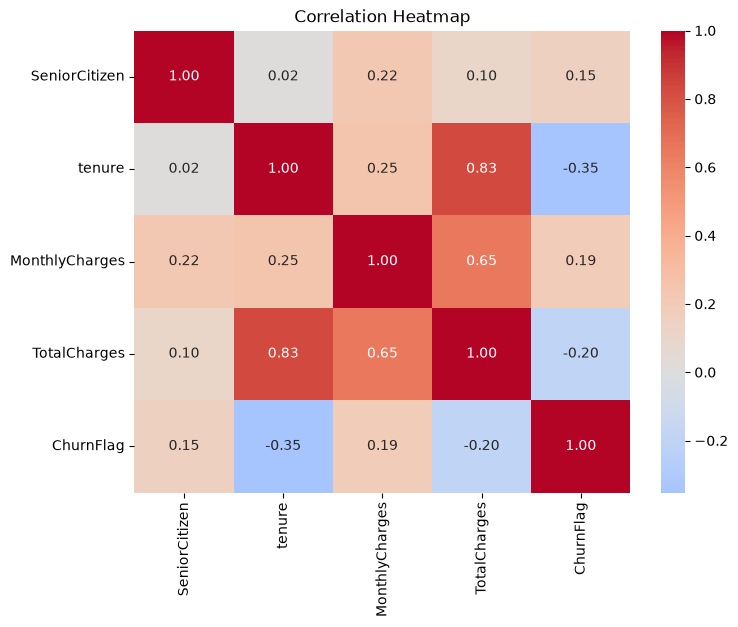

In [72]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

### Correlation Insights

The correlation analysis shows several useful relationships with churn:

- `tenure` has the strongest numerical relationship with churn, with a correlation of approximately **-0.35**. This indicates that customers with longer tenure tend to churn less.
- `MonthlyCharges` has a positive correlation of approximately **0.19** with churn, suggesting that customers with higher monthly charges are somewhat more likely to churn.
- `SeniorCitizen` has a weak positive correlation of approximately **0.15** with churn.
- `TotalCharges` has a negative correlation of approximately **-0.20** with churn. This is expected because customers with higher total charges are often customers who have stayed with the company for longer.

The heatmap also shows a strong correlation between `tenure` and `TotalCharges` of approximately **0.83**. This makes sense because customers who stay longer generally accumulate higher total charges.

Correlation only captures linear relationships and only applies directly to numerical variables. Important categorical variables such as Contract, Internet Service, Tech Support, and Payment Method are therefore better understood through the earlier churn-rate analysis.

# Final EDA Findings

The exploratory analysis identified several customer characteristics that are strongly associated with churn.

### Key Findings

**1. Overall Churn**
- Approximately **26.5%** of customers in the dataset churned.

**2. Contract Type**
- Month-to-month customers had a churn rate of approximately **42.7%**.
- One-year customers had a churn rate of approximately **11.3%**.
- Two-year customers had the lowest churn rate at approximately **2.8%**.

Contract type appears to be one of the strongest churn-related customer characteristics.

**3. Customer Tenure**
- Churned customers had an average tenure of approximately **18 months**.
- Non-churned customers had an average tenure of approximately **38 months**.
- Churn was concentrated more heavily among newer customers.

**4. Monthly Charges**
- Churned customers had higher average monthly charges, approximately **74.4**, compared with approximately **61.3** for non-churned customers.

**5. Internet Service**
- Fiber optic customers had the highest churn rate at approximately **41.9%**.
- DSL customers had a churn rate of approximately **19.0%**.
- Customers without internet service had a churn rate of approximately **7.4%**.

**6. Payment Method**
- Customers using electronic checks had a churn rate of approximately **45.3%**, considerably higher than customers using other payment methods.
- Automatic payment methods were associated with lower churn rates.

**7. Customer Demographics**
- Senior customers had a higher churn rate than non-senior customers.
- Customers without partners or dependents also showed higher churn rates.

**8. Support and Security Services**
- Customers without Tech Support had a churn rate of approximately **41.6%**, compared with approximately **15.2%** for customers with Tech Support.
- Customers without Online Security had a churn rate of approximately **41.8%**, compared with approximately **14.6%** for customers with Online Security.

**9. Additional Services**
- Online Backup and Device Protection showed noticeable differences in churn between subscribers and non-subscribers.
- Streaming TV, Streaming Movies, and Multiple Lines showed comparatively smaller differences.

### Overall Business Interpretation

The analysis suggests that higher-risk customers tend to have combinations of characteristics such as shorter tenure, month-to-month contracts, higher monthly charges, Fiber optic internet service, electronic check payments, and the absence of support or security services.

These findings identify useful customer segments for retention analysis and provide direction for feature engineering and predictive modeling.

The relationships identified during EDA represent associations rather than proof of causation.